In [1]:
from datasets import load_dataset
posts = load_dataset("trl-lib/tldr")

c:\Users\Bruger\miniconda3\envs\nlp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def getSubredditFromPost(post):
    return  post['prompt'].split('\n')[0][11:];

counts = {}
subreddits = []
for post in posts['train']:
    subreddit = getSubredditFromPost(post)
    if subreddit not in subreddits:
        subreddits.append(subreddit)
    if(subreddit in counts):
        counts[subreddit] = counts[subreddit] + 1
    else:
        counts[subreddit] = 1

amount_of_posts_to_evaluate = min(counts.values())


In [3]:
def getSubredditFromPost(post):
    return  post['prompt'].split('\n')[0][11:];

counts = {}
subreddits = []
for post in posts['train']:
    subreddit = getSubredditFromPost(post)
    if subreddit not in subreddits:
        subreddits.append(subreddit)
    if(subreddit in counts):
        counts[subreddit] = counts[subreddit] + 1
    else:
        counts[subreddit] = 1

for post in posts['test']:
    subreddit = getSubredditFromPost(post)
    if subreddit not in subreddits:
        subreddits.append(subreddit)
    if(subreddit in counts):
        counts[subreddit] = counts[subreddit] + 1
    else:
        counts[subreddit] = 1

for post in posts['validation']:
    subreddit = getSubredditFromPost(post)
    if subreddit not in subreddits:
        subreddits.append(subreddit)
    if(subreddit in counts):
        counts[subreddit] = counts[subreddit] + 1
    else:
        counts[subreddit] = 1

amount_of_posts_to_evaluate = min(counts.values())
counts

{'r/relationships': 70325,
 'r/loseit': 1624,
 'r/personalfinance': 2583,
 'r/offmychest': 1731,
 'r/relationship_advice': 9641,
 'r/dating_advice': 3170,
 'r/dogs': 705,
 'r/legaladvice': 2200,
 'r/AskReddit': 17224,
 'r/running': 638,
 'r/tifu': 8523,
 'r/needadvice': 580,
 'r/cats': 364,
 'r/Advice': 2320,
 'r/BreakUps': 946,
 'r/pettyrevenge': 610,
 'r/self': 1179,
 'r/GetMotivated': 193,
 'r/Parenting': 483,
 'r/weddingplanning': 476,
 'r/college': 309,
 'r/jobs': 1191,
 'r/Dogtraining': 404,
 'r/Pets': 410,
 'r/Cooking': 121,
 'r/askwomenadvice': 762,
 'r/AskDocs': 323,
 'r/travel': 504,
 'r/books': 183}

In [4]:
# Use a pipeline as a high-level helper
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1

pipe = pipeline("summarization", model="google/pegasus-xsum", device=0)

c:\Users\Bruger\miniconda3\envs\nlp\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Bruger\.cache\huggingface\hub\models--google--pegasus-xsum. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP do

In [ ]:
# (C) Andrew Foland, Sonnetiq, 2024; license granted under Apache 2.0
import torch
from transformers import AutoModel, AutoTokenizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def calculate_cosine_similarity(vector1, vector2):
    # Calculate cosine similarity between two vectors
    return cosine_similarity([vector1], [vector2])[0][0]

def embed_string(text, model, tokenizer):
    input_ids = tokenizer.encode(text, return_tensors='pt', max_length=512, truncation=True)
    with torch.no_grad():
        embedding = model(input_ids).last_hidden_state.mean(dim=1).squeeze().tolist()
    return embedding

def NOIR(text, summary, embedding_model = "sentence-transformers/all-MiniLM-L6-v2"): #change here - it makes model hver gang
    model = AutoModel.from_pretrained(embedding_model)
    tokenizer = AutoTokenizer.from_pretrained(embedding_model)

    text_embedding = embed_string(text, model, tokenizer)
    summary_embedding = embed_string(summary, model, tokenizer)
    D = calculate_cosine_similarity(text_embedding, summary_embedding)

    text_length = len(tokenizer.encode(text))
    summary_length = len(tokenizer.encode(summary))
    k = summary_length / text_length

    sque_metric = np.log(k) / np.log(D)
    return sque_metric

In [13]:
import time
import evaluate

noirScores = {}
bleurtScores = {}
rougeScores = {}
counter = 0

rouge = evaluate.load("rouge")
bleurt = evaluate.load("bleurt", module_type="metric")

for subreddit in subreddits:
  noirScores[subreddit] = []
  sub_dataset = posts.filter(lambda post : getSubredditFromPost(post) == subreddit)
  start = time.time()
  completions = []
  labels = []
  #for post in sub_dataset['train'].select(range(amount_of_posts_to_evaluate)):
  for post in sub_dataset['train'].select(range(5)):
    generatedText = pipe(post['prompt'])
    
    noirScore = NOIR(post['prompt'], generatedText[0]['summary_text'])
    noirScores[subreddit].append(noirScore)

    completions.append(generatedText[0]['summary_text'])
    labels.append(post['completion'])

  bleurtScore = bleurt.compute(predictions=completions, references=labels)
  bleurtScores[subreddit] = bleurtScore['scores']

  rougeScore = rouge.compute(predictions=completions, references=labels)
  rougeScores[subreddit] = rougeScore

  end = time.time()
  print("Time: " + str(end-start))



INFO:tensorflow:Reading checkpoint C:\Users\Bruger\.cache\huggingface\metrics\bleurt\default\downloads\extracted\48268fdd2275c6770bfc2bae27f0b7350297e67459005b4af66dcadb1743f780\bleurt-base-128.


INFO:tensorflow:Reading checkpoint C:\Users\Bruger\.cache\huggingface\metrics\bleurt\default\downloads\extracted\48268fdd2275c6770bfc2bae27f0b7350297e67459005b4af66dcadb1743f780\bleurt-base-128.


INFO:tensorflow:Config file found, reading.


INFO:tensorflow:Config file found, reading.


INFO:tensorflow:Will load checkpoint bert_custom


...

Time: 8.204420804977417


Filter: 100%|██████████| 6553/6553 [00:00<00:00, 85079.50 examples/s]


Time: 8.743056774139404


Filter: 100%|██████████| 6553/6553 [00:00<00:00, 90243.47 examples/s]
C:\Users\Bruger\AppData\Local\Temp\ipykernel_22344\888451628.py:29: RuntimeWarning: invalid value encountered in log
  sque_metric = np.log(k) / np.log(D)


Time: 10.483711242675781


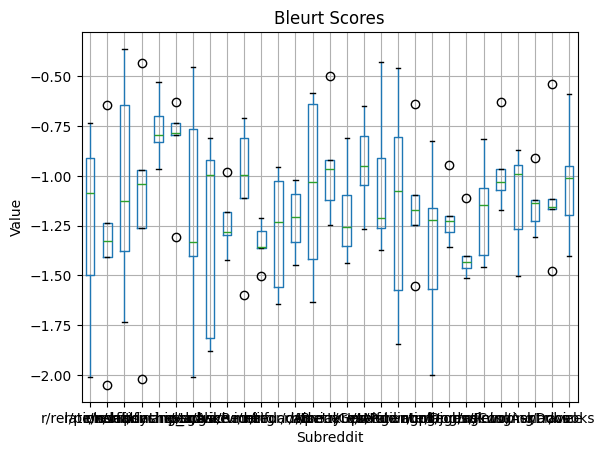

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Example DataFrame
df = pd.DataFrame(bleurtScores)

df.boxplot()
plt.title("Bleurt Scores")
plt.xlabel("Subreddit")
plt.ylabel("Value")
plt.show()

In [ ]:
df

,r/relationships,r/loseit,r/personalfinance,r/offmychest,r/relationship_advice,r/dating_advice,r/dogs,r/legaladvice,r/AskReddit,r/running,...,r/weddingplanning,r/college,r/jobs,r/Dogtraining,r/Pets,r/Cooking,r/askwomenadvice,r/AskDocs,r/travel,r/books
0,-1.499813,-1.327755,-1.375889,-0.431372,-0.827770,-1.305395,-1.404227,-1.879678,-0.979190,-1.112796,...,-1.245914,-1.999833,-0.944159,-1.402915,-1.458936,-0.627622,-0.992021,-0.908217,-1.479856,-1.011097
1,-0.735844,-2.049102,-1.733413,-0.970118,-0.968005,-0.737005,-0.765239,-0.809393,-1.299268,-1.595966,...,-1.552003,-1.570207,-1.227572,-1.432409,-0.815929,-1.071910,-0.943676,-1.123258,-1.156003,-0.590716
2,-0.908076,-1.236633,-1.125820,-1.263339,-0.697152,-0.782837,-1.333742,-0.995378,-1.422081,-0.810771,...,-0.637035,-1.221092,-1.202033,-1.514823,-1.397100,-1.170611,-1.503156,-1.136066,-1.164961,-0.950430
3,-2.008573,-1.406703,-0.362146,-2.018612,-0.529068,-0.627663,-2.009048,-0.919507,-1.284387,-0.996065,...,-1.170628,-0.825617,-1.355809,-1.110629,-1.061214,-1.029725,-1.267059,-1.226127,-1.117854,-1.196518
4,-1.085984,-0.646891,-0.641952,-1.038713,-0.792893,-0.795440,-0.455485,-1.812203,-1.182841,-0.707445,...,-1.094148,-1.161261,-1.281769,-1.464733,-1.146688,-0.965556,-0.871446,-1.305465,-0.540310,-1.400665


In [38]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.8.0+cu126
12.6
CUDA available: True
NVIDIA GeForce RTX 3070 Laptop GPU


In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
